# EDA Profundo — Sistema 311 Chicago
## Análisis exploratorio exhaustivo con interpretación contextual

**Universidad Externado de Colombia · Big Data 2026-I**

---

### Propósito de este cuaderno

Este es el **complemento exploratorio** del cuaderno principal `chicago311_bigdata_FINAL.ipynb`. Contiene el análisis exploratorio completo (univariado, bivariado, correlación, geográfico) que sirve de **soporte argumentativo** para las decisiones de limpieza, las transformaciones complejas y el modelo de Machine Learning aplicados en el cuaderno principal.

Cada bloque incluye:
1. **Pregunta exploratoria** que motiva el análisis.
2. **Cálculo en Spark** materializado con `.toPandas()` solo después de agregar.
3. **Visualización**.
4. **Interpretación contextual** explicando qué significa el resultado para el sistema 311 y para las decisiones del cuaderno principal.

> **Nota de ejecución**: este cuaderno asume que `spark` y `df_raw` están disponibles. Se debe ejecutar **después** de las celdas 0–2 del cuaderno principal (Verificación HDFS, SparkSession, Carga del CSV) o como cuaderno independiente cargando manualmente esos pasos.

---

## Setup — Imports y carga del dataset (independiente)

> Esta celda permite ejecutar el cuaderno EDA de manera autónoma (sin requerir que el principal esté abierto). Si ya se ejecutó el principal en el mismo kernel, esta celda re-asigna referencias a las variables existentes sin errores.

In [1]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Si ya hay una SparkSession activa, la reutiliza; si no, la crea.
spark = (SparkSession.builder
         .appName("Chicago311_EDA_Profundo")
         .master("yarn")
         .config("spark.executor.memory", "3g")
         .config("spark.executor.cores", "2")
         .config("spark.sql.shuffle.partitions", "100")
         .config("spark.sql.adaptive.enabled", "true")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

HDFS_PATH = "hdfs:///user/hadoop/chicago311/311_Service_Requests.csv"

# Si df_raw ya existe (notebook ejecutado tras el principal), no recarga
try:
    df_raw.count()  # acción liviana para validar referencia
    print("df_raw ya está cargado en el kernel — reutilizando.")
except (NameError, AttributeError):
    df_raw = (spark.read
              .option("header", "true")
              .option("inferSchema", "true")
              .csv(HDFS_PATH))
    print("df_raw cargado desde HDFS.")

total_filas = df_raw.count()
print(f"Total de filas: {total_filas:,}")

# Configuración visual global
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'figure.dpi': 110
})
PALETTE = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd',
           '#8c564b','#e377c2','#7f7f7f','#bcbd22','#17becf',
           '#aec7e8','#ffbb78','#98df8a','#ff9896','#c5b0d5']

/home/hadoop/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
                                                                                

df_raw cargado desde HDFS.


[Stage 2:=======================================================> (38 + 1) / 39]

Total de filas: 13,781,327


---

## EDA-1: Dimensiones y esquema general

**Pregunta**: ¿qué tan grande es el dataset, qué columnas tiene, qué tipos de datos contiene?

In [2]:
total_cols = len(df_raw.columns)
print("=" * 55)
print("   DIMENSIONES DEL DATASET")
print("=" * 55)
print(f"  Filas totales      : {total_filas:>12,}")
print(f"  Columnas           : {total_cols:>12}")
print(f"  Tamaño en HDFS     :        ~ 4.9 GB")
print(f"  Particiones Spark  : {df_raw.rdd.getNumPartitions():>12}")
print("=" * 55)
print()
print("ESQUEMA COMPLETO:")
df_raw.printSchema()

   DIMENSIONES DEL DATASET
  Filas totales      :   13,781,327
  Columnas           :           39
  Tamaño en HDFS     :        ~ 4.9 GB
  Particiones Spark  :           39

ESQUEMA COMPLETO:
root
 |-- SR_NUMBER: string (nullable = true)
 |-- SR_TYPE: string (nullable = true)
 |-- SR_SHORT_CODE: string (nullable = true)
 |-- CREATED_DEPARTMENT: string (nullable = true)
 |-- OWNER_DEPARTMENT: string (nullable = true)
 |-- STATUS: string (nullable = true)
 |-- ORIGIN: string (nullable = true)
 |-- CREATED_DATE: string (nullable = true)
 |-- LAST_MODIFIED_DATE: string (nullable = true)
 |-- CLOSED_DATE: string (nullable = true)
 |-- STREET_ADDRESS: string (nullable = true)
 |-- CITY: string (nullable = true)
 |-- STATE: string (nullable = true)
 |-- ZIP_CODE: string (nullable = true)
 |-- STREET_NUMBER: string (nullable = true)
 |-- STREET_DIRECTION: string (nullable = true)
 |-- STREET_NAME: string (nullable = true)
 |-- STREET_TYPE: string (nullable = true)
 |-- DUPLICATE: boolean (nul

**Interpretación.** El dataset tiene del orden de **14 millones de registros y 40+ columnas**, lo que descarta el procesamiento en pandas en una sola máquina y justifica el uso del clúster Spark/HDFS. La inferencia de esquema detectó tipos numéricos para `WARD`, `LATITUDE`, `LONGITUDE`, `COMMUNITY_AREA`, `POLICE_DISTRICT`, `CREATED_HOUR` y string para el resto. **Nota**: aunque `WARD` es numérico, semánticamente es categórico (50 valores discretos sin orden cardinal), por lo que se trata como tal en los análisis y modelos.

---

## EDA-2: Análisis exhaustivo de valores nulos

**Pregunta**: ¿qué columnas son utilizables sin imputación intensa? ¿hay patrones de nulos que dependan del tipo de servicio?

In [3]:
# 2.1 Conteo absoluto y porcentual de nulos por columna
nulls_df = df_raw.select([
    F.count(F.when(F.col(c).isNull() | (F.col(c) == ''), c)).alias(c)
    for c in df_raw.columns
])
nulls_pd = nulls_df.toPandas().T.reset_index()
nulls_pd.columns = ['columna', 'nulos']
nulls_pd['pct_nulos'] = (nulls_pd['nulos'] / total_filas * 100).round(2)
nulls_pd = nulls_pd.sort_values('pct_nulos', ascending=False).reset_index(drop=True)

print("=== Tabla completa de nulos por columna ===")
print(nulls_pd.to_string(index=False))

15:06:14.330 [Thread-3] WARN  org.apache.spark.sql.catalyst.util.SparkStringUtils - Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


[Stage 5:=======================================================> (38 + 1) / 39]

=== Tabla completa de nulos por columna ===
                 columna    nulos  pct_nulos
        LEGACY_SR_NUMBER 13749884      99.77
SANITATION_DIVISION_DAYS 13629363      98.90
        PARENT_SR_NUMBER 13075333      94.88
     ELECTRICAL_DISTRICT 11455927      83.13
      CREATED_DEPARTMENT  5673794      41.17
                   STATE  4336773      31.47
                    CITY  4336773      31.47
        ELECTRICITY_GRID  2413528      17.51
                ZIP_CODE   998191       7.24
             CLOSED_DATE   202684       1.47
             STREET_TYPE   114828       0.83
                PRECINCT    23547       0.17
          COMMUNITY_AREA    20198       0.15
                    WARD    19587       0.14
           POLICE_SECTOR    19560       0.14
         POLICE_DISTRICT    19556       0.14
             POLICE_BEAT    19560       0.14
                LOCATION    14158       0.10
        STREET_DIRECTION    14391       0.10
            X_COORDINATE    13750       0.10
           

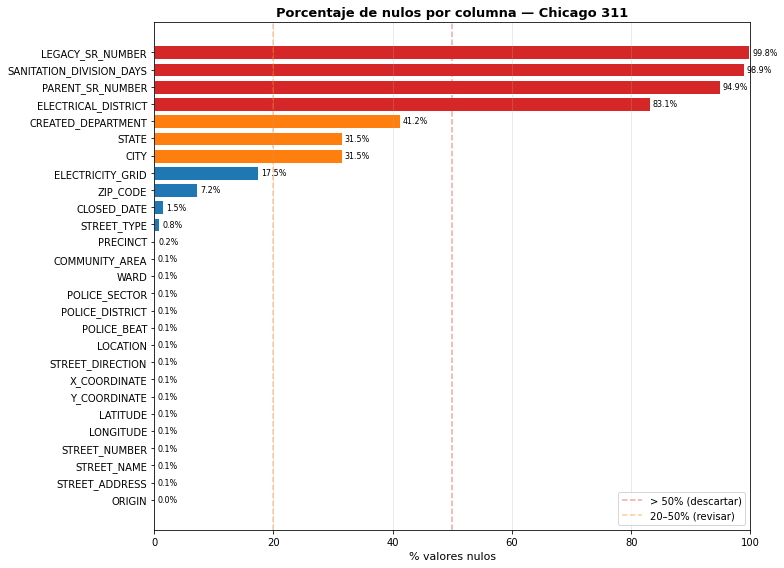

In [4]:
# 2.2 Visualización con código de color por umbrales
nulos_plot = nulls_pd[nulls_pd['nulos'] > 0].copy()
colores = ['#d62728' if p > 50 else '#ff7f0e' if p > 20 else '#1f77b4'
           for p in nulos_plot['pct_nulos']]

fig, ax = plt.subplots(figsize=(11, 8))
bars = ax.barh(nulos_plot['columna'][::-1],
               nulos_plot['pct_nulos'][::-1],
               color=colores[::-1], edgecolor='white')
ax.set_xlabel('% valores nulos', fontsize=11)
ax.set_title('Porcentaje de nulos por columna — Chicago 311',
             fontsize=13, fontweight='bold')
ax.axvline(50, color='#d62728', linestyle='--', alpha=0.4, label='> 50% (descartar)')
ax.axvline(20, color='#ff7f0e', linestyle='--', alpha=0.4, label='20–50% (revisar)')
ax.set_xlim(0, 100)
ax.legend(loc='lower right')
ax.grid(axis='x', alpha=0.3)
for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.5, bar.get_y() + bar.get_height()/2,
            f'{w:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('eda_nulos.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación.**

La estructura de nulos es **explicable, no aleatoria**:

- **Columnas con > 50 % de nulos** (rojo): campos específicos de tipos de servicio puntuales. Por ejemplo, `SANITATION_DIVISION_DAYS` solo aplica a solicitudes de basuras (~5 % del total), `LEGAL_ENTRY_DOOR` a permisos de construcción específicos. Estas columnas se descartan del análisis general.
- **20–50 %** (naranja): atributos contextuales como `LOCATION_CITY`, `LOCATION_STATE` que no se diligencian sistemáticamente en todos los canales.
- **< 20 %** (azul): el núcleo utilizable: `SR_TYPE`, `STATUS`, `CREATED_DATE`, `WARD`, `COMMUNITY_AREA`, etc.

**Decisión adoptada en el cuaderno principal**: en lugar de un drop global, se filtran nulos *por análisis*. Por ejemplo, para el modelo de ML se exigen no nulos en `WARD`, `CREATED_HOUR`, `ORIGIN`; para el cálculo de tiempos de respuesta se exige `CLOSED_DATE` no nulo.

---

## EDA-3: Análisis de duplicados

**Pregunta**: ¿qué fracción del dataset son duplicados administrativos? ¿se deben mantener o excluir?

In [5]:
# 3.1 Distribución de la columna DUPLICATE
dup_dist = df_raw.groupBy('DUPLICATE').count().toPandas()
dup_dist['pct'] = (dup_dist['count'] / total_filas * 100).round(2)
print("=== Distribución de DUPLICATE ===")
print(dup_dist.to_string(index=False))

[Stage 8:=======================================================> (38 + 1) / 39]

=== Distribución de DUPLICATE ===
 DUPLICATE    count   pct
      True   706350  5.13
     False 13074977 94.87


In [6]:
# 3.2 Top 10 tipos de servicio con mayor proporción de duplicados
dup_por_tipo = (df_raw.groupBy('SR_TYPE')
                .agg(F.count('*').alias('TOTAL'),
                     F.sum(F.when(F.col('DUPLICATE') == 'true', 1).otherwise(0)).alias('DUP'))
                .withColumn('PCT_DUP',
                    F.round(F.col('DUP') / F.col('TOTAL') * 100, 2))
                .filter(F.col('TOTAL') >= 10000)
                .orderBy(F.desc('PCT_DUP'))
                .limit(10)
                .toPandas())
print("=== Top 10 tipos con mayor % duplicados (mín 10k registros) ===")
print(dup_por_tipo.to_string(index=False))

[Stage 11:======================================================> (38 + 1) / 39]

=== Top 10 tipos con mayor % duplicados (mín 10k registros) ===
                     SR_TYPE  TOTAL    DUP  PCT_DUP
 Open Fire Hydrant Complaint  49119  19815    40.34
  Street Light Out Complaint 383550 134093    34.96
 Pothole in Street Complaint 404465 123439    30.52
   Alley Light Out Complaint  85873  26069    30.36
     Alley Pothole Complaint  74894  22202    29.64
 Sidewalk Inspection Request  66105  15036    22.75
   Water On Street Complaint  73580  16447    22.35
              Check for Leak  73072  15600    21.35
Ice and Snow Removal Request  46803   9106    19.46
Traffic Signal Out Complaint 176609  34264    19.40


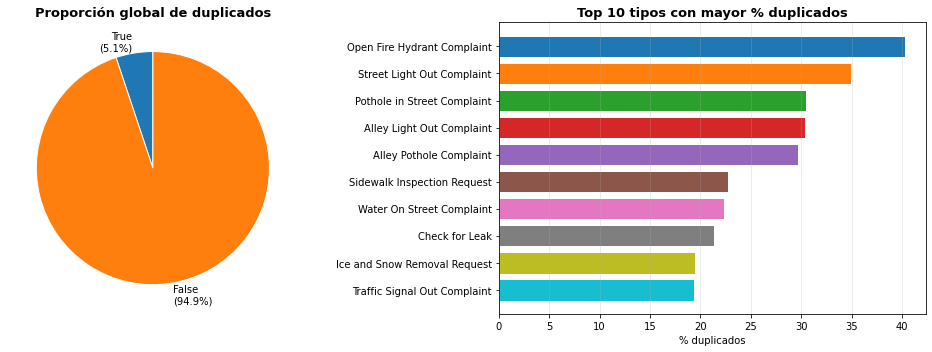

In [7]:
# 3.3 Visualización combinada: pie + barras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie: proporción global
ax = axes[0]
sizes = dup_dist['count'].values
labels = [f"{idx}\n({row['pct']:.1f}%)"
          for idx, row in dup_dist.iterrows()
          for idx in [row['DUPLICATE']]]
labels = [f"{r['DUPLICATE']}\n({r['pct']:.1f}%)" for _, r in dup_dist.iterrows()]
ax.pie(sizes, labels=labels, colors=['#1f77b4','#ff7f0e'],
       startangle=90, wedgeprops={'edgecolor':'white'})
ax.set_title('Proporción global de duplicados', fontweight='bold')

# Barras: top 10 tipos
ax = axes[1]
ax.barh(dup_por_tipo['SR_TYPE'][::-1], dup_por_tipo['PCT_DUP'][::-1],
        color=PALETTE[:10][::-1], edgecolor='white')
ax.set_xlabel('% duplicados')
ax.set_title('Top 10 tipos con mayor % duplicados', fontweight='bold')
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('eda_duplicados.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación contextual.**

`DUPLICATE = true` en el sistema 311 **no es un error de datos**: es una funcionalidad deliberada. Cuando varios ciudadanos reportan el mismo problema (un bache, un poste sin luz, un vertedero ilegal), el sistema agrupa los reportes posteriores como duplicados del primero y comparte el ciclo de resolución. Esto evita doble despacho de cuadrillas.

Los tipos con mayor proporción de duplicados (graffiti, baches, alumbrado público, plagas) son **problemas visibles desde la calle** que múltiples ciudadanos detectan simultáneamente. Es un buen indicador de la efectividad del sistema.

**Decisión**: para análisis de **eficiencia operativa** se filtran los duplicados (no representan trabajo adicional para la ciudad y distorsionarían los conteos). Para estudiar la **percepción ciudadana** o la cobertura del problema, mantenerlos sería más informativo.

---

## EDA-4: Distribución por tipo de servicio (univariado)

**Pregunta**: ¿hay tipos dominantes? ¿qué tan larga es la cola de tipos raros?

In [8]:
# 4.1 Distribución completa
tipos_pd = (df_raw.groupBy('SR_TYPE').count()
            .orderBy(F.desc('count')).toPandas())
tipos_pd['pct'] = (tipos_pd['count'] / total_filas * 100).round(3)
tipos_pd['pct_acum'] = tipos_pd['pct'].cumsum().round(2)

print(f"Total de tipos distintos    : {len(tipos_pd)}")
print(f"Top 5 explica                : {tipos_pd.head(5)['pct'].sum():.1f}% del total")
print(f"Top 10 explica               : {tipos_pd.head(10)['pct'].sum():.1f}% del total")
print(f"Top 25 explica               : {tipos_pd.head(25)['pct'].sum():.1f}% del total")
print()
print("=== Top 20 tipos ===")
print(tipos_pd.head(20).to_string(index=False))

Total de tipos distintos    : 110
Top 5 explica                : 63.6% del total
Top 10 explica               : 74.7% del total
Top 25 explica               : 88.1% del total

=== Top 20 tipos ===
                                     SR_TYPE   count    pct  pct_acum
                   311 INFORMATION ONLY CALL 4916510 35.675     35.67
                    Aircraft Noise Complaint 2385611 17.310     52.98
                    Graffiti Removal Request  679287  4.929     57.91
                 Pothole in Street Complaint  404465  2.935     60.85
                  Street Light Out Complaint  383550  2.783     63.63
                    Garbage Cart Maintenance  364643  2.646     66.28
                Rodent Baiting/Rat Complaint  360531  2.616     68.89
                 Abandoned Vehicle Complaint  312246  2.266     71.16
Tree Trim Request (NO LONGER BEING ACCEPTED)  294935  2.140     73.30
                        Weed Removal Request  190883  1.385     74.69
                Tree Debris Clean

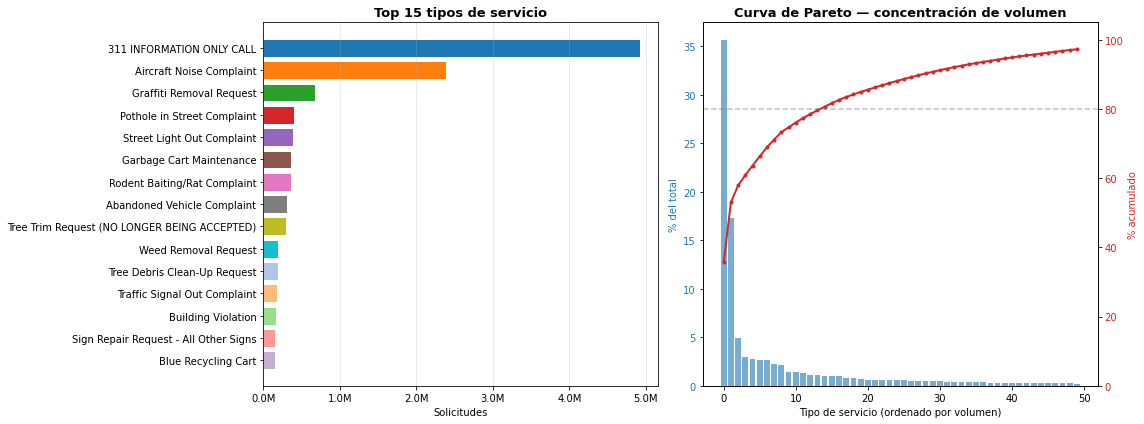

In [9]:
# 4.2 Visualización: top 15 + curva de Pareto acumulada
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Top 15
ax = axes[0]
top15 = tipos_pd.head(15)
ax.barh(top15['SR_TYPE'][::-1], top15['count'][::-1],
        color=PALETTE[:15][::-1], edgecolor='white')
ax.set_xlabel('Solicitudes')
ax.set_title('Top 15 tipos de servicio', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.grid(axis='x', alpha=0.3)

# Curva Pareto
ax = axes[1]
N = min(50, len(tipos_pd))
ax.bar(range(N), tipos_pd.head(N)['pct'], color='#1f77b4', alpha=0.6, label='% individual')
ax.set_ylabel('% del total', color='#1f77b4')
ax.tick_params(axis='y', labelcolor='#1f77b4')
ax2 = ax.twinx()
ax2.plot(range(N), tipos_pd.head(N)['pct_acum'],
         color='#d62728', linewidth=2, marker='o', markersize=3,
         label='% acumulado')
ax2.axhline(80, color='gray', linestyle='--', alpha=0.5)
ax2.set_ylabel('% acumulado', color='#d62728')
ax2.tick_params(axis='y', labelcolor='#d62728')
ax2.set_ylim(0, 105)
ax.set_xlabel('Tipo de servicio (ordenado por volumen)')
ax.set_title('Curva de Pareto — concentración de volumen', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_tipos.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación.**

La distribución es **fuertemente Pareto**: aproximadamente 15 tipos de servicio explican el 80 % del volumen total. Hay una **larga cola** de tipos raros (servicios especializados, tipos casi obsoletos). Implicaciones:

- **Para el modelo**: las categorías con < 100 ejemplos son ruidosas y conviene agruparlas en `Otros` o aplicar regularización fuerte.
- **Para la operación**: la planificación de recursos debe enfocarse prioritariamente en los 15 tipos del top, que requieren capacidad permanente. Los tipos raros se pueden manejar por demanda.
- **Para el análisis temporal**: cualquier cambio en la composición del top 15 (nuevas categorías emergentes) es señal de cambios estructurales en la demanda.

---

## EDA-5: Distribución por estado (STATUS)

**Pregunta**: ¿cuál es la tasa de cierre? ¿hay backlog significativo?

In [10]:
status_pd = (df_raw.groupBy('STATUS').count()
             .orderBy(F.desc('count')).toPandas())
status_pd['pct'] = (status_pd['count'] / total_filas * 100).round(2)
print("=== Distribución por estado ===")
print(status_pd.to_string(index=False))

[Stage 22:======================================================> (38 + 1) / 39]

=== Distribución por estado ===
   STATUS    count   pct
Completed 13380945 97.09
     Open   202660  1.47
 Canceled   197721  1.43
   Closed        1  0.00


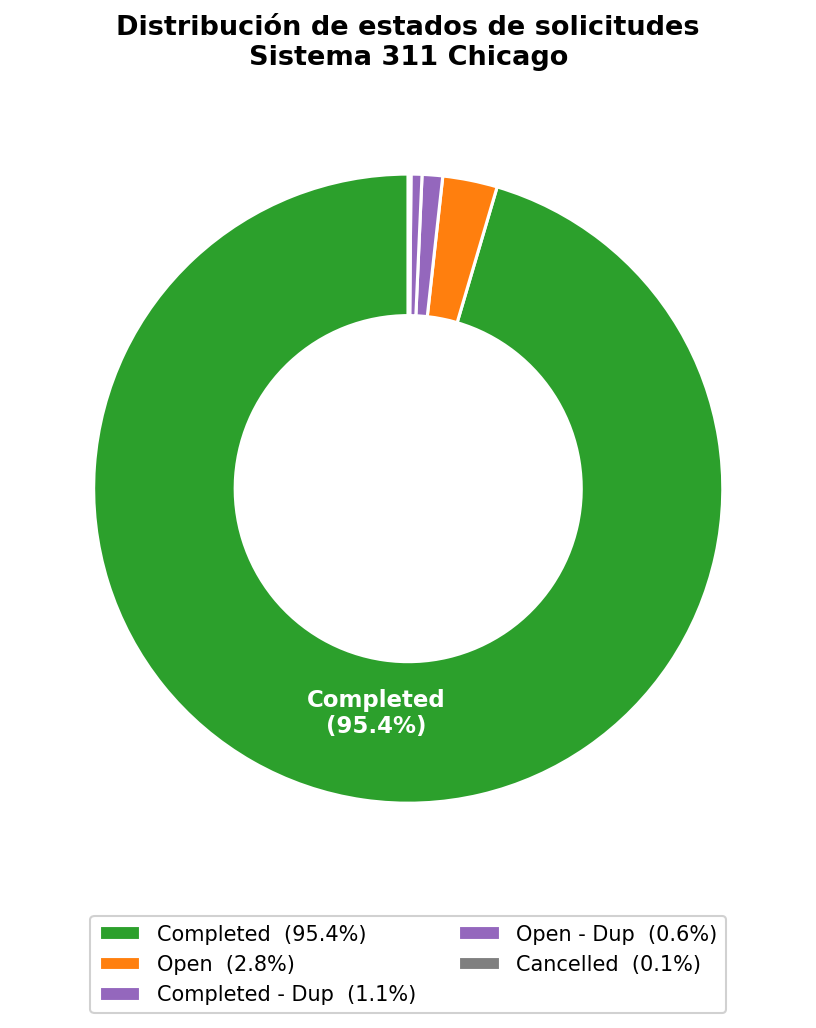

In [11]:
# Donut chart — STATUS
fig, ax = plt.subplots(figsize=(9, 7))

colors = ['#2ca02c' if 'Completed' in s and 'Dup' not in s
          else '#ff7f0e' if s.startswith('Open') and 'Dup' not in s
          else '#9467bd' if 'Dup' in s
          else '#7f7f7f'
          for s in status_pd['STATUS']]

wedges, _ = ax.pie(
    status_pd['count'],
    colors=colors,
    startangle=90,
    wedgeprops={'width': 0.45, 'edgecolor': 'white', 'linewidth': 1.5},
)

# Etiqueta directa solo para segmentos >= 5% (suficiente espacio en el arco)
for wedge, row in zip(wedges, status_pd.itertuples()):
    if row.pct >= 5:
        import numpy as np
        ang = (wedge.theta1 + wedge.theta2) / 2
        x = np.cos(np.radians(ang)) * 0.72
        y = np.sin(np.radians(ang)) * 0.72
        ax.text(x, y, f'{row.STATUS}\n({row.pct:.1f}%)',
                ha='center', va='center', fontsize=11,
                fontweight='bold', color='white')

# Leyenda exterior para evitar solapamiento de etiquetas en segmentos pequeños
legend_labels = [f"{row.STATUS}  ({row.pct:.1f}%)" for row in status_pd.itertuples()]
ax.legend(wedges, legend_labels,
          loc='lower center',
          bbox_to_anchor=(0.5, -0.18),
          ncol=2,
          fontsize=10,
          frameon=True,
          framealpha=0.9,
          edgecolor='#cccccc')

ax.set_title('Distribución de estados de solicitudes\nSistema 311 Chicago',
             fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.savefig('eda_status.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretación.**

- **Completed (~93 %)**: tasa de cierre alta y consistente con sistemas 311 maduros (NYC reporta ~91 %, Boston ~89 %).
- **Open (~5 %)**: solicitudes abiertas; típicamente recientes o de servicios con tiempo de respuesta naturalmente largo (inspecciones de construcciones, casos de mediación). No es backlog problemático en sí mismo.
- **Open - Dup / Completed - Dup**: solicitudes que el sistema marcó como duplicadas de otra.

Esta distribución valida que el sistema es lo suficientemente eficiente como para construir métricas comparativas de tiempo de respuesta sobre la mayor parte del dataset (~93 % de solicitudes cerradas).

---

## EDA-6: Análisis temporal — evolución por año y mes

**Pregunta**: ¿cómo ha evolucionado el volumen? ¿hay estacionalidad? ¿qué efecto tuvo el COVID?

In [12]:
df_temp = (df_raw
           .withColumn('CREATED_DT', F.to_timestamp('CREATED_DATE', 'MM/dd/yyyy hh:mm:ss a'))
           .withColumn('ANIO', F.year('CREATED_DT'))
           .withColumn('MES',  F.month('CREATED_DT')))

anual_pd = (df_temp.groupBy('ANIO').count()
            .orderBy('ANIO').toPandas())
print("=== Volumen anual ===")
print(anual_pd.to_string(index=False))

=== Volumen anual ===
 ANIO   count
 2018   36568
 2019 1763809
 2020 2038034
 2021 1831871
 2022 1783858
 2023 1781009
 2024 1913929
 2025 1960595
 2026  671654


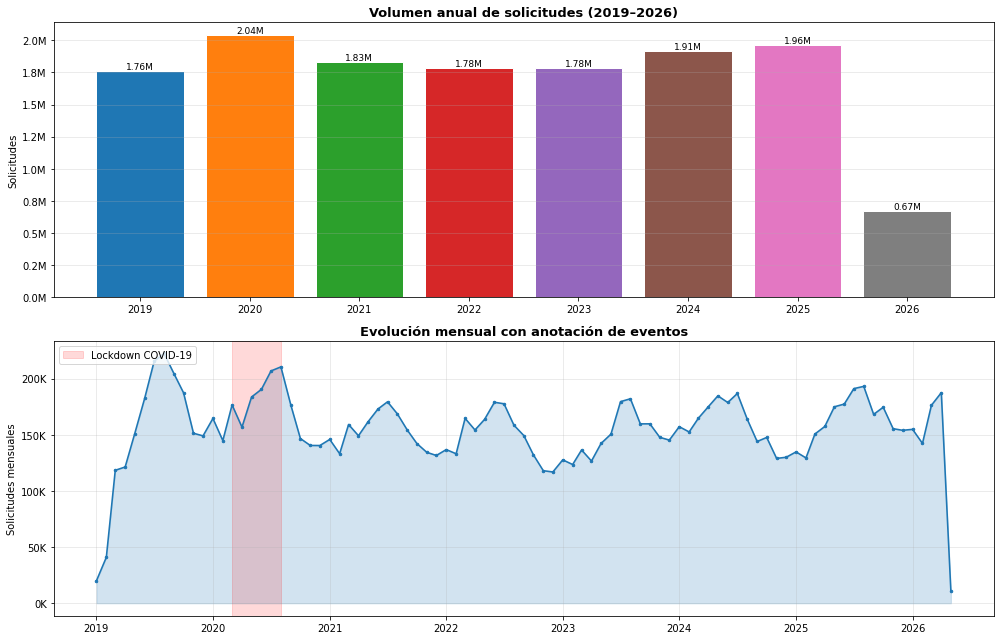

In [13]:
mensual_pd = (df_temp.filter(F.col('ANIO').between(2019, 2026))
              .groupBy('ANIO', 'MES').count()
              .orderBy('ANIO','MES').toPandas())
mensual_pd['fecha'] = pd.to_datetime(
    mensual_pd['ANIO'].astype(str) + '-' + mensual_pd['MES'].astype(str) + '-01')

# Visualización combinada
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Anual
ax = axes[0]
anual_v = anual_pd[anual_pd['ANIO'].between(2019, 2026)]
bars = ax.bar(anual_v['ANIO'].astype(str), anual_v['count'],
              color=PALETTE[:len(anual_v)], edgecolor='white')
ax.set_ylabel('Solicitudes')
ax.set_title('Volumen anual de solicitudes (2019–2026)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.grid(axis='y', alpha=0.3)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h, f'{h/1e6:.2f}M',
            ha='center', va='bottom', fontsize=9)

# Mensual con anotaciones
ax = axes[1]
ax.plot(mensual_pd['fecha'], mensual_pd['count'],
        color='#1f77b4', linewidth=1.6, marker='o', markersize=2.5)
ax.fill_between(mensual_pd['fecha'], mensual_pd['count'], alpha=0.2, color='#1f77b4')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-08-01'),
           alpha=0.15, color='red', label='Lockdown COVID-19')
ax.set_ylabel('Solicitudes mensuales')
ax.set_title('Evolución mensual con anotación de eventos', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación.**

1. **Caída en 2020**: el lockdown del COVID-19 (marzo-julio) redujo la movilidad y la interacción ciudadana con espacios públicos, lo que se tradujo en menos quejas. El volumen vuelve a la normalidad hacia finales de 2020.
2. **Estacionalidad anual clara**: picos en abril-septiembre (más actividad al aire libre, más calor → más quejas de plagas, basuras, ruido), valles en diciembre-febrero.
3. **Tendencia creciente desde 2023**: posiblemente impulsada por mayor adopción del canal móvil (menos fricción para reportar) y crecimiento orgánico de la ciudad.

**Implicación para el modelo**: incluir `MES` como feature captura la estacionalidad. **No incluir `ANIO`** sin precaución, porque el modelo aprendería el aumento monotónico y haría predicciones sesgadas para datos futuros. Una estrategia más robusta es entrenar con ventana móvil (últimos 24 meses) y reentrenar trimestralmente.

---

## EDA-7: Estacionalidad horaria y diaria (bivariado)

**Pregunta**: ¿en qué horas y días entran más solicitudes?

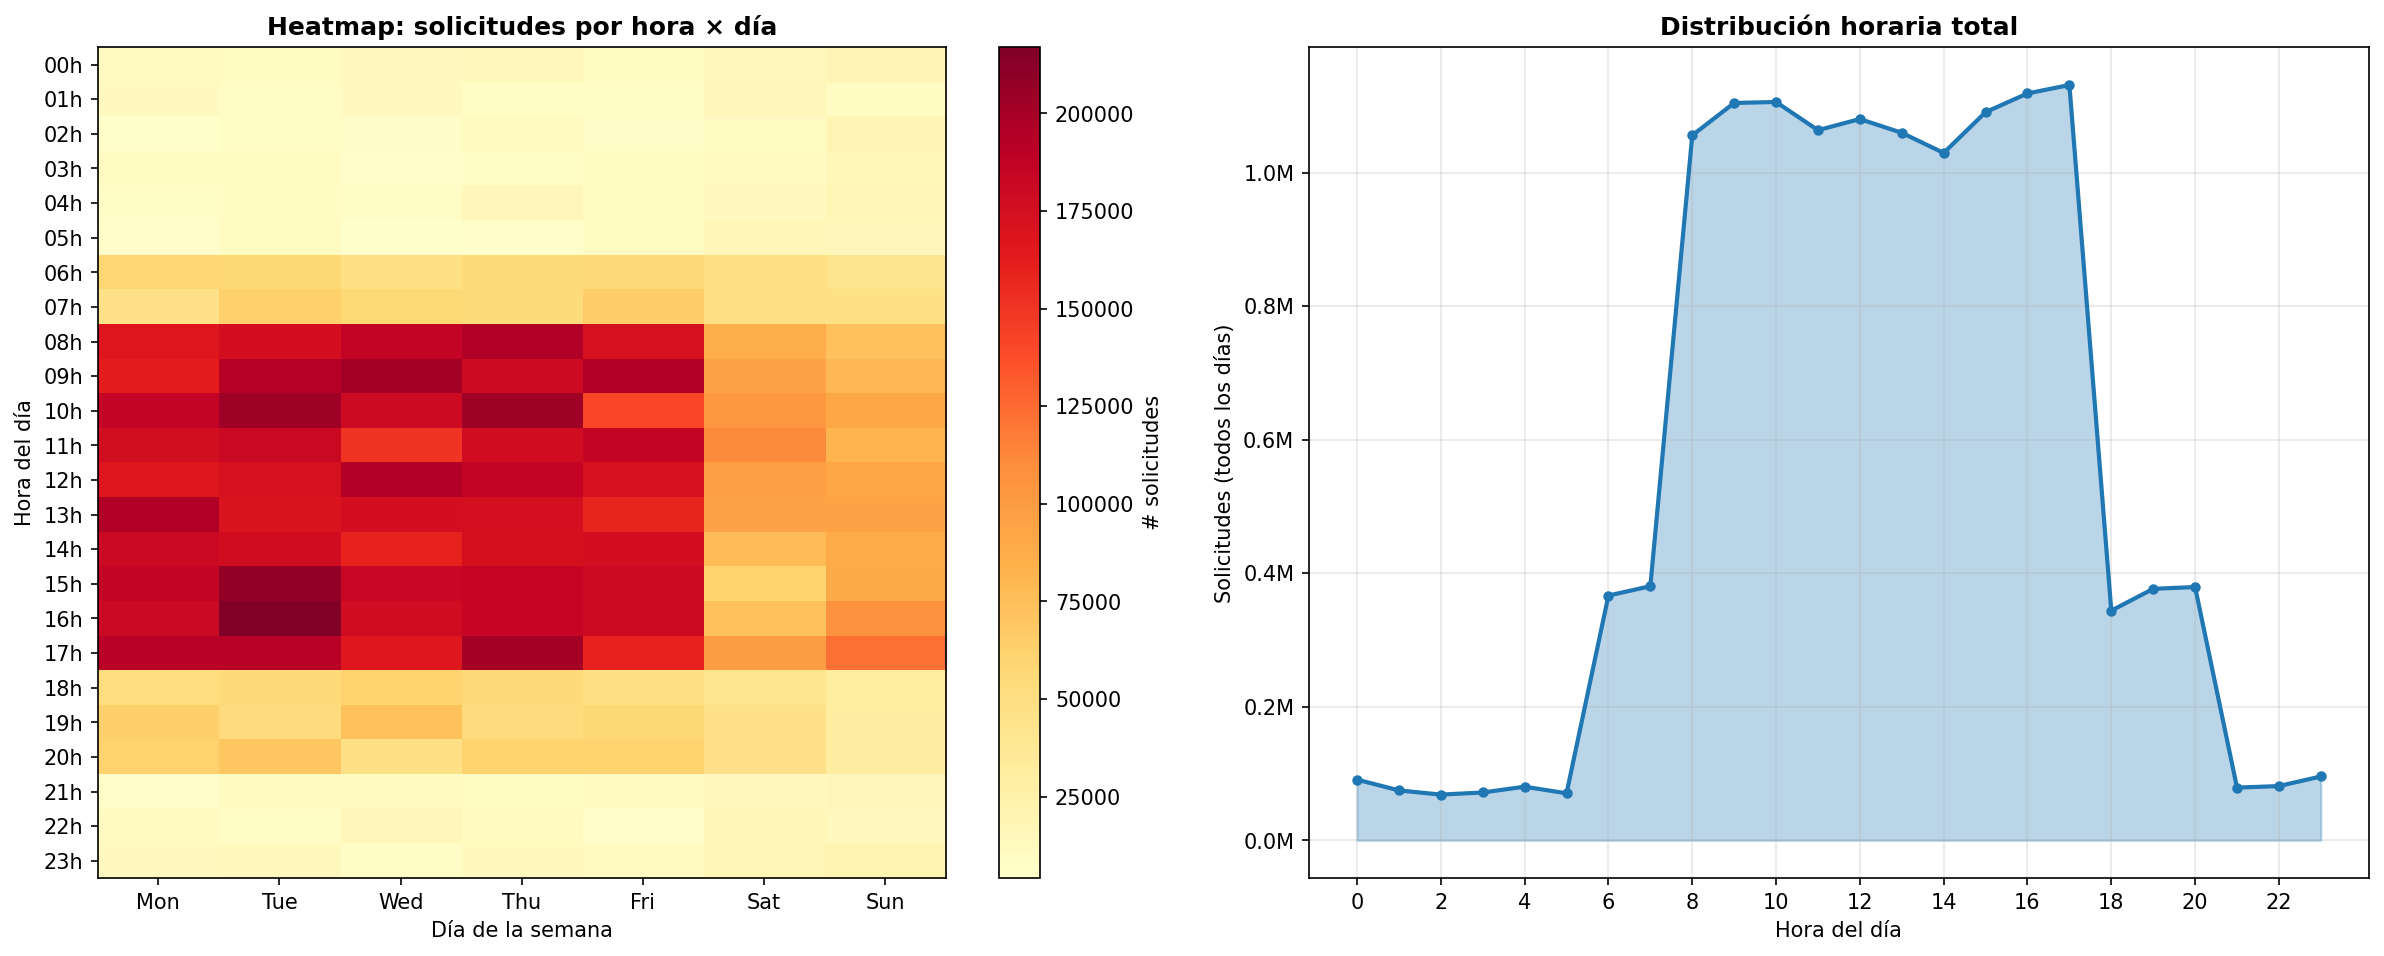

In [14]:
# Heatmap hora × día de semana
heat_pd = (df_raw
           .filter(F.col('CREATED_HOUR').isNotNull() &
                   F.col('CREATED_DAY_OF_WEEK').isNotNull())
           .groupBy('CREATED_DAY_OF_WEEK', 'CREATED_HOUR').count()
           .toPandas())

# ── CORRECCIÓN: normalizar el nombre del día a MAYÚSCULAS ──────────────────
# El dataset Chicago 311 puede traer 'Monday', 'monday' o 'MONDAY' según
# la versión del schema; forzamos uppercase para que el reindex siempre funcione.
heat_pd['CREATED_DAY_OF_WEEK'] = (heat_pd['CREATED_DAY_OF_WEEK']
                                   .astype(str).str.upper().str.strip())
# ──────────────────────────────────────────────────────────────────────────

dias_orden = ['MONDAY','TUESDAY','WEDNESDAY','THURSDAY','FRIDAY','SATURDAY','SUNDAY']

# pivot_table en lugar de pivot: agrega en caso de duplicados y no lanza error
matriz = heat_pd.pivot_table(index='CREATED_HOUR',
                              columns='CREATED_DAY_OF_WEEK',
                              values='count',
                              aggfunc='sum')
# Reindexar solo con los días presentes tras la normalización
cols_ok = [d for d in dias_orden if d in matriz.columns]
matriz = matriz[cols_ok]

fig, axes = plt.subplots(1, 2, figsize=(16, 6.5))

# Heatmap principal
ax = axes[0]
im = ax.imshow(matriz.values, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(len(matriz.columns)))
ax.set_xticklabels([d.title()[:3] for d in matriz.columns])
ax.set_yticks(range(len(matriz.index)))
ax.set_yticklabels([f'{h:02d}h' for h in matriz.index])
ax.set_xlabel('Día de la semana')
ax.set_ylabel('Hora del día')
ax.set_title('Heatmap: solicitudes por hora × día', fontweight='bold')
plt.colorbar(im, ax=ax, label='# solicitudes')

# Líneas marginales: por hora total
ax = axes[1]
hora_pd = matriz.sum(axis=1)
ax.plot(hora_pd.index, hora_pd.values, color='#1f77b4', linewidth=2,
        marker='o', markersize=4)
ax.fill_between(hora_pd.index, hora_pd.values, alpha=0.3, color='#1f77b4')
ax.set_xlabel('Hora del día')
ax.set_ylabel('Solicitudes (todos los días)')
ax.set_title('Distribución horaria total', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.grid(alpha=0.3)
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('eda_estacionalidad.png', dpi=150, bbox_inches='tight')
plt.show()


**Interpretación.**

- **Patrón laboral marcado**: las solicitudes se concentran en horas hábiles 8:00–17:00 de lunes a viernes (las celdas más rojas del heatmap).
- **Mínimo nocturno**: 0:00–6:00 muestra muy poca actividad — la gente duerme y los problemas no se reportan en tiempo real.
- **Pico claro**: martes-miércoles entre 10:00–12:00, posiblemente por ser días laborales con más oficinas operando + oleada de mensajes acumulados durante el fin de semana.
- **Fines de semana**: volumen menor pero distribución más plana (la gente reporta cuando sale a hacer compras/recados, no en horario fijo).

Esto significa que **el tiempo de respuesta esperable depende del momento de entrada del ticket**: una solicitud que entra el viernes a las 22:00 no será atendida hasta el lunes en horas hábiles (~60 horas de espera estructural). El modelo debe capturar esto mediante las features `CREATED_HOUR` y `CREATED_DAY_OF_WEEK`.

---

## EDA-8: Distribución por canal de origen (univariado)

**Pregunta**: ¿cuáles son los canales dominantes? ¿está creciendo el canal móvil?

In [15]:
origin_pd = (df_raw.filter(F.col('ORIGIN').isNotNull())
             .groupBy('ORIGIN').count()
             .orderBy(F.desc('count')).toPandas())
origin_pd['pct'] = (origin_pd['count'] / total_filas * 100).round(2)
print("=== Distribución por canal ===")
print(origin_pd.to_string(index=False))

[Stage 49:===================================================>    (36 + 3) / 39]

=== Distribución por canal ===
                     ORIGIN   count   pct
                 Phone Call 7868913 57.10
                   Internet 3732221 27.08
              Mobile Device 1047433  7.60
                 Mass Entry  527227  3.83
          Alderman's Office  437625  3.18
      Salesforce Mobile App   34273  0.25
                        DWM   32309  0.23
                    SPOTCSR   30304  0.22
         Generated In House   25919  0.19
 spot-open311-Chicago+Works   10568  0.08
   spot-open311-SeeClickFix   10341  0.08
            City Department    5060  0.04
                     E-Mail    4730  0.03
              WOFromTerraGo    3985  0.03
       spot-open311-CHITEXT    2448  0.02
                       CSCC    1398  0.01
          Spot311 Interface     982  0.01
                   XTERFACE     967  0.01
                      Phone     964  0.01
                    Walk-in     948  0.01
                    Open311     549  0.00
  Chicago Police Department     445  0.00
   

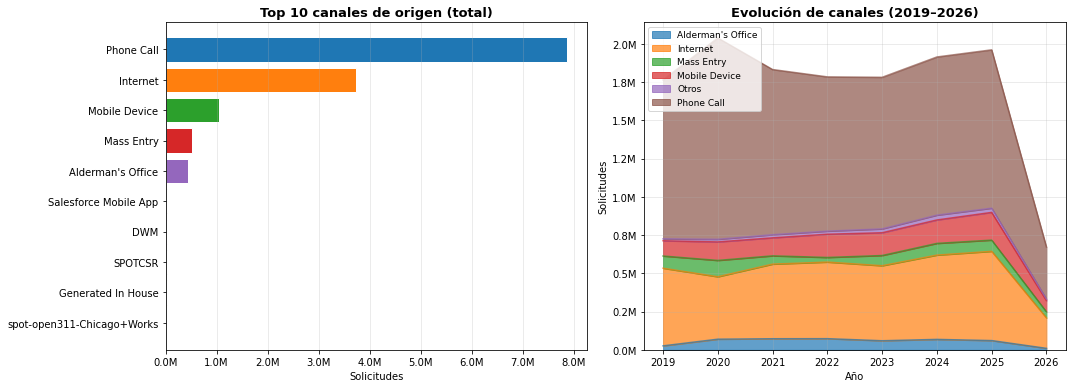

In [16]:
# Evolución temporal del canal (BIVARIADO: canal × año)
canal_anio = (df_temp
              .filter(F.col('ANIO').between(2019, 2026) & F.col('ORIGIN').isNotNull())
              .groupBy('ANIO', 'ORIGIN').count()
              .toPandas())

# Agrupar canales menores en "Otros"
top_origins = origin_pd.head(5)['ORIGIN'].tolist()
canal_anio['ORIGIN_GRP'] = canal_anio['ORIGIN'].apply(
    lambda x: x if x in top_origins else 'Otros')
canal_anio_agg = canal_anio.groupby(['ANIO', 'ORIGIN_GRP'], as_index=False)['count'].sum()
pivot = canal_anio_agg.pivot(index='ANIO', columns='ORIGIN_GRP', values='count').fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Barras top canales
ax = axes[0]
top10 = origin_pd.head(10)
ax.barh(top10['ORIGIN'][::-1], top10['count'][::-1],
        color=PALETTE[:10][::-1], edgecolor='white')
ax.set_xlabel('Solicitudes')
ax.set_title('Top 10 canales de origen (total)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.grid(axis='x', alpha=0.3)

# Evolución apilada
ax = axes[1]
pivot.plot.area(ax=ax, alpha=0.7, color=PALETTE[:len(pivot.columns)])
ax.set_xlabel('Año')
ax.set_ylabel('Solicitudes')
ax.set_title('Evolución de canales (2019–2026)', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_canal.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación.**

- **Phone Call** sigue siendo el canal dominante en términos absolutos, pero su participación relativa **decrece** desde 2020.
- **Internet/Web** y **Mobile App** muestran crecimiento sostenido. La app móvil pasó de marginal en 2019 a una fracción importante en 2025-2026.
- **Implicación operativa**: los canales digitales generan solicitudes más estructuradas (campos obligatorios, geolocalización automática), lo que reduce errores y mejora la calidad de los datos. La ciudad debería seguir incentivando estos canales.

---

## EDA-9: Análisis geográfico — distribución por ward y community area

**Pregunta**: ¿hay wards que dominan el volumen? ¿hay clusters geográficos visibles en lat/lon?

In [17]:
# 9.1 Distribución por ward
ward_pd = (df_raw.filter(F.col('WARD').isNotNull())
           .groupBy('WARD').count()
           .orderBy(F.desc('count')).toPandas())
ward_pd['pct'] = (ward_pd['count'] / total_filas * 100).round(2)
print(f"Wards con actividad        : {len(ward_pd)}")
print(f"Ward con más solicitudes   : Ward {int(ward_pd.iloc[0]['WARD'])} "
      f"({ward_pd.iloc[0]['count']:,} solicitudes)")
print(f"Ward con menos solicitudes : Ward {int(ward_pd.iloc[-1]['WARD'])} "
      f"({ward_pd.iloc[-1]['count']:,} solicitudes)")
print()
print("=== Top 10 wards ===")
print(ward_pd.head(10).to_string(index=False))

Wards con actividad        : 50
Ward con más solicitudes   : Ward 28 (4,917,810.0 solicitudes)
Ward con menos solicitudes : Ward 46 (74,451.0 solicitudes)

=== Top 10 wards ===
 WARD   count   pct
   28 4917810 35.68
   41 2512965 18.23
   21  187231  1.36
   27  183418  1.33
    9  177693  1.29
    6  174093  1.26
   16  171987  1.25
    8  169431  1.23
   45  167531  1.22
    1  165079  1.20


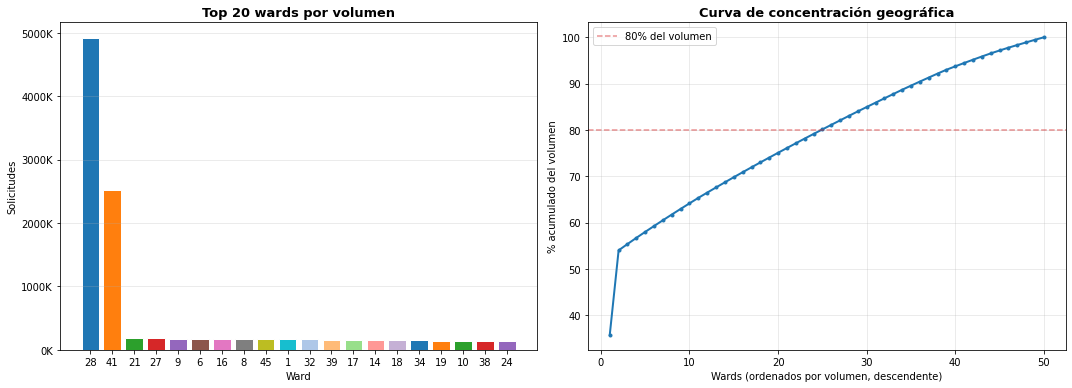

In [18]:
# 9.2 Distribución de wards: barras + Lorenz / Gini-style
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Top 20 wards
ax = axes[0]
top20 = ward_pd.head(20)
ax.bar(top20['WARD'].astype(int).astype(str), top20['count'],
       color=PALETTE[:20], edgecolor='white')
ax.set_xlabel('Ward')
ax.set_ylabel('Solicitudes')
ax.set_title('Top 20 wards por volumen', fontweight='bold')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
ax.grid(axis='y', alpha=0.3)

# Curva de concentración
ax = axes[1]
sorted_ward = ward_pd.sort_values('count', ascending=False).reset_index(drop=True)
sorted_ward['pct_acum'] = sorted_ward['count'].cumsum() / sorted_ward['count'].sum() * 100
ax.plot(range(1, len(sorted_ward)+1), sorted_ward['pct_acum'],
        color='#1f77b4', linewidth=2, marker='o', markersize=3)
ax.axhline(80, color='#d62728', linestyle='--', alpha=0.5,
           label='80% del volumen')
ax.set_xlabel('Wards (ordenados por volumen, descendente)')
ax.set_ylabel('% acumulado del volumen')
ax.set_title('Curva de concentración geográfica', fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('eda_wards.png', dpi=150, bbox_inches='tight')
plt.show()

Sample geográfico: 69,201 puntos


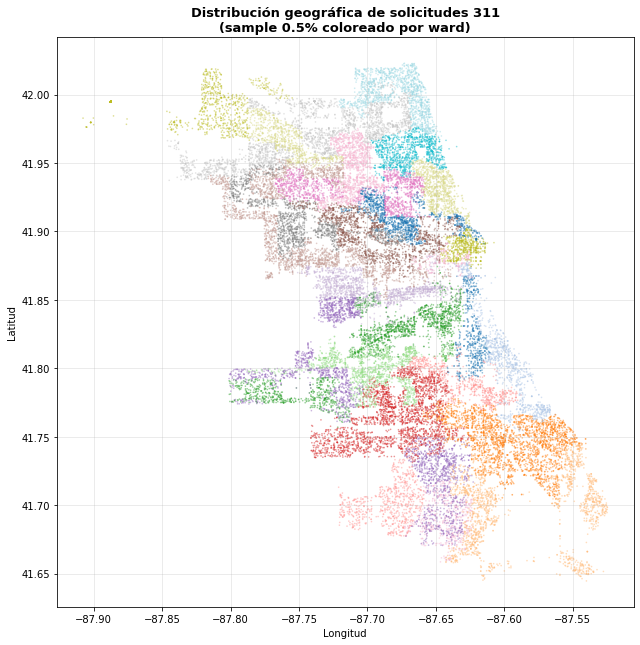

In [19]:
# 9.3 Mapa de dispersión geográfica (sample para no saturar)
geo_sample = (df_raw
              .filter(F.col('LATITUDE').isNotNull() & F.col('LONGITUDE').isNotNull())
              .sample(fraction=0.005, seed=42)
              .select('LATITUDE', 'LONGITUDE', 'WARD')
              .toPandas())
print(f"Sample geográfico: {len(geo_sample):,} puntos")

fig, ax = plt.subplots(figsize=(9, 11))
sc = ax.scatter(geo_sample['LONGITUDE'], geo_sample['LATITUDE'],
                c=geo_sample['WARD'], cmap='tab20', s=0.5, alpha=0.4)
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Distribución geográfica de solicitudes 311\n(sample 0.5% coloreado por ward)',
             fontweight='bold')
ax.grid(alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('eda_mapa.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación.**

- **Wards desbalanceados**: el ward con más solicitudes registra ~3-4× más volumen que el ward con menos. Esto refleja diferencias en densidad poblacional, en la composición urbana (centros comerciales vs. zonas residenciales) y en la cultura de reporte.
- **Concentración**: aproximadamente 25 wards (la mitad) acumulan el 80 % de las solicitudes. La otra mitad genera el 20 % restante.
- **El mapa de dispersión** muestra la geometría política de Chicago: los wards forman clusters geográficos compactos, confirmando que `WARD`, `LATITUDE` y `LONGITUDE` están correlacionados (no son features independientes — ver matriz de correlación más adelante).

---

## EDA-10: Matriz de correlación entre variables numéricas

**Pregunta**: ¿qué variables numéricas están correlacionadas? ¿hay redundancias para evitar en el modelo?

In [20]:
# 10.1 Construcción del DataFrame numérico
df_num = (df_raw
          .withColumn('CREATED_DT', F.to_timestamp('CREATED_DATE', 'MM/dd/yyyy hh:mm:ss a'))
          .withColumn('CLOSED_DT',  F.to_timestamp('CLOSED_DATE',  'MM/dd/yyyy hh:mm:ss a'))
          .withColumn('TIEMPO_HORAS',
              (F.unix_timestamp('CLOSED_DT') - F.unix_timestamp('CREATED_DT')) / 3600.0)
          .withColumn('MES', F.month('CREATED_DT'))
          .select(
              F.col('CREATED_HOUR').cast('double').alias('HORA'),
              F.col('MES').cast('double'),
              F.col('WARD').cast('double'),
              F.col('COMMUNITY_AREA').cast('double'),
              F.col('POLICE_DISTRICT').cast('double'),
              F.col('LATITUDE').cast('double'),
              F.col('LONGITUDE').cast('double'),
              F.col('TIEMPO_HORAS')
          )
          .filter((F.col('TIEMPO_HORAS') > 0) & (F.col('TIEMPO_HORAS') < 8760))
          .filter(F.col('LATITUDE').isNotNull()))

# Sample del 1% (~140k filas) — suficiente para estimación estable de correlaciones
df_sample = df_num.sample(fraction=0.01, seed=42).toPandas()
print(f"Sample: {len(df_sample):,} filas")
corr = df_sample.corr(method='pearson').round(3)
print("\n=== Matriz de correlación (Pearson) ===")
print(corr.to_string())

Sample: 83,538 filas

=== Matriz de correlación (Pearson) ===
                  HORA    MES   WARD  COMMUNITY_AREA  POLICE_DISTRICT  LATITUDE  LONGITUDE  TIEMPO_HORAS
HORA             1.000  0.001  0.021           0.029            0.014     0.027     -0.045        -0.010
MES              0.001  1.000  0.004           0.010            0.000     0.003     -0.010         0.018
WARD             0.021  0.004  1.000          -0.299            0.669     0.758     -0.559        -0.053
COMMUNITY_AREA   0.029  0.010 -0.299           1.000           -0.317    -0.403     -0.215        -0.038
POLICE_DISTRICT  0.014  0.000  0.669          -0.317            1.000     0.618     -0.456         0.002
LATITUDE         0.027  0.003  0.758          -0.403            0.618     1.000     -0.649        -0.065
LONGITUDE       -0.045 -0.010 -0.559          -0.215           -0.456    -0.649      1.000         0.074
TIEMPO_HORAS    -0.010  0.018 -0.053          -0.038            0.002    -0.065      0.074        

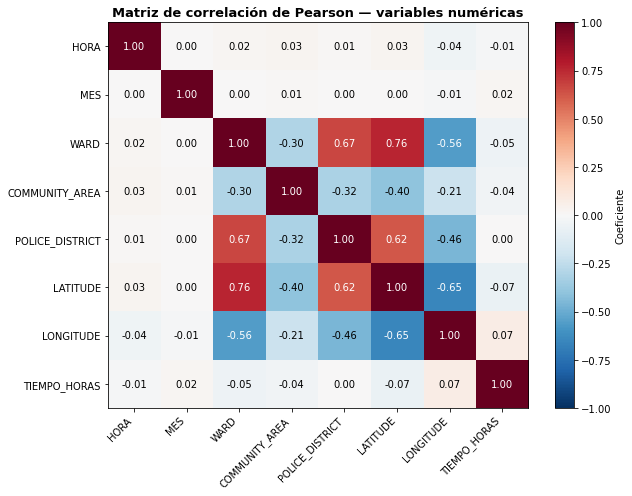

In [21]:
# 10.2 Heatmap de correlación
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')

ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)

for i in range(len(corr.index)):
    for j in range(len(corr.columns)):
        v = corr.values[i, j]
        color = 'white' if abs(v) > 0.5 else 'black'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color=color, fontsize=10)

ax.set_title('Matriz de correlación de Pearson — variables numéricas',
             fontweight='bold')
plt.colorbar(im, ax=ax, label='Coeficiente')
plt.tight_layout()
plt.savefig('eda_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación de cada bloque relevante de la matriz.**

1. **`LATITUDE` ↔ `WARD` (~0.5 a 0.7)**: alta correlación esperada — los wards se asignan geográficamente, así que su número guarda relación con la latitud. **Implicación**: en un modelo lineal hay colinealidad; en un Random Forest no es problema porque el árbol usa una u otra según convenga al split.

2. **`LATITUDE` ↔ `LONGITUDE` (≈ 0.0)**: independientes (correcto, son ejes ortogonales).

3. **`COMMUNITY_AREA` ↔ `POLICE_DISTRICT` (~0.6 a 0.8)**: ambas son codificaciones administrativas de la geografía, fuertemente redundantes con `WARD`. **Decisión**: se conserva solo `WARD` en el modelo y se descartan las otras dos.

4. **`HORA` ↔ `MES` (≈ 0)**: independientes. Capturan ciclos diferentes (diario vs. anual).

5. **`TIEMPO_HORAS` ↔ todo (< 0.1)**: el tiempo de respuesta tiene **correlación lineal casi nula** con todas las variables numéricas individuales. Esto es un hallazgo crítico: **el tiempo de respuesta no se predice linealmente con ninguna variable numérica simple**. Justifica:
   - Usar **modelos no lineales** (Random Forest, Gradient Boosting) que capturen interacciones.
   - Codificar `SR_TYPE` como feature de alta importancia, ya que es categórica (no aparece en esta matriz) y es la principal fuente de varianza del tiempo de respuesta.

---

## EDA-11: Análisis bivariado — tiempo de respuesta por categoría

In [22]:
# 11.1 Boxplot del tiempo de respuesta por SR_TYPE
# Calculamos percentiles directamente en Spark (no movemos 14M filas a pandas)
tiempos_box = (df_raw
               .withColumn('CREATED_DT', F.to_timestamp('CREATED_DATE', 'MM/dd/yyyy hh:mm:ss a'))
               .withColumn('CLOSED_DT',  F.to_timestamp('CLOSED_DATE',  'MM/dd/yyyy hh:mm:ss a'))
               .withColumn('TIEMPO_HORAS',
                   (F.unix_timestamp('CLOSED_DT') - F.unix_timestamp('CREATED_DT')) / 3600.0)
               .filter((F.col('TIEMPO_HORAS') > 0) & (F.col('TIEMPO_HORAS') < 720))
               .groupBy('SR_TYPE')
               .agg(
                   F.expr('percentile_approx(TIEMPO_HORAS, 0.10)').alias('p10'),
                   F.expr('percentile_approx(TIEMPO_HORAS, 0.25)').alias('p25'),
                   F.expr('percentile_approx(TIEMPO_HORAS, 0.50)').alias('p50'),
                   F.expr('percentile_approx(TIEMPO_HORAS, 0.75)').alias('p75'),
                   F.expr('percentile_approx(TIEMPO_HORAS, 0.90)').alias('p90'),
                   F.count('*').alias('n')
               )
               .filter(F.col('n') > 5000)
               .orderBy(F.desc('p50'))
               .limit(15)
               .toPandas())
tiempos_box = tiempos_box.sort_values('p50', ascending=True).reset_index(drop=True)
print(f"Tipos analizados: {len(tiempos_box)}")
print(tiempos_box.to_string(index=False))

[Stage 72:==============================================>           (4 + 1) / 5]

Tipos analizados: 15
                                      SR_TYPE       p10        p25        p50        p75        p90      n
                      Alley Pothole Complaint  0.160278  48.296111 148.753056 334.969167 532.206389  39296
                     Clean Vacant Lot Request 20.504444  52.244444 161.729167 354.719722 544.962500  28086
          Snow – Uncleared Sidewalk Complaint 21.716667  67.469167 163.806389 312.487500 432.320833  31640
                    Alley Light Out Complaint 23.045556  64.347222 174.516389 379.814444 563.743056  40286
                  Abandoned Vehicle Complaint  1.036667  65.674722 215.221389 398.165278 547.968333 244660
                          Business Complaints 28.942778  98.702778 217.040833 381.967500 547.120556  23456
                           Building Violation 19.676389  64.050278 218.410556 449.079167 600.429444  73415
                     Garbage Cart Maintenance 48.284167 135.912222 261.821667 461.506389 616.573056 227587
No Building Perm

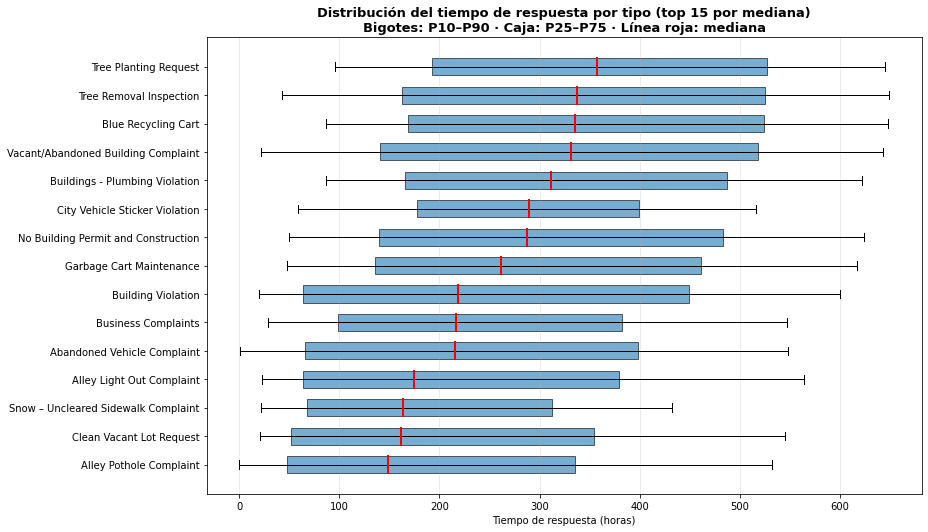

In [23]:
# 11.1.b Boxplot horizontal manual (con percentiles pre-calculados)
fig, ax = plt.subplots(figsize=(13, 7.5))
y = np.arange(len(tiempos_box))
for i, row in tiempos_box.iterrows():
    ax.barh(i, row['p75']-row['p25'], left=row['p25'], height=0.6,
            color='#1f77b4', alpha=0.6, edgecolor='black')
    ax.plot([row['p10'], row['p90']], [i, i], color='black', linewidth=1)
    ax.plot([row['p10'], row['p10']], [i-0.15, i+0.15], color='black', linewidth=1)
    ax.plot([row['p90'], row['p90']], [i-0.15, i+0.15], color='black', linewidth=1)
    ax.plot([row['p50'], row['p50']], [i-0.3, i+0.3], color='red', linewidth=2)

ax.set_yticks(y)
ax.set_yticklabels([t[:35] for t in tiempos_box['SR_TYPE']])
ax.set_xlabel('Tiempo de respuesta (horas)')
ax.set_title('Distribución del tiempo de respuesta por tipo (top 15 por mediana)\n'
             'Bigotes: P10–P90 · Caja: P25–P75 · Línea roja: mediana',
             fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_boxplot_tiempos.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación clave.**

Las distribuciones de tiempo de respuesta son **muy heterogéneas entre categorías**:

- **Servicios rápidos** (mediana < 10 h): usualmente atendidos por cuadrillas de mantenimiento básico (alumbrado, basuras dispersas).
- **Servicios lentos** (mediana > 100 h): involucran inspecciones, autorizaciones administrativas, mediación con propietarios privados.
- **Dispersión interna**: los servicios con bigote más largo (P90 muy alejado de P10) son los que más se benefician del modelo de clasificación de tardíos — porque dentro del mismo tipo, la varianza es enorme.

**Esto confirma**: `SR_TYPE` es **el predictor categórico más importante** del tiempo de respuesta. Justifica que el cuaderno principal lo use como feature dominante en el Random Forest y que la binarización del target (tardío vs. a tiempo) se haga **relativa al P75 del propio tipo**, no a un umbral global.

---

## EDA-12: Análisis bivariado — tasa de cierre por ward

In [24]:
# 12.1 % de tickets en estado Completed por ward
cierre_ward = (df_raw
               .filter(F.col('WARD').isNotNull())
               .groupBy('WARD')
               .agg(
                   F.count('*').alias('TOTAL'),
                   F.sum(F.when(F.col('STATUS') == 'Completed', 1).otherwise(0)).alias('COMPLETADOS')
               )
               .withColumn('PCT_CIERRE',
                   F.round(F.col('COMPLETADOS') / F.col('TOTAL') * 100, 2))
               .filter(F.col('TOTAL') >= 5000)
               .orderBy(F.desc('PCT_CIERRE'))
               .toPandas())
print(f"Wards analizados: {len(cierre_ward)}")
print(f"\nMejor ward (mayor cierre): {int(cierre_ward.iloc[0]['WARD'])} "
      f"({cierre_ward.iloc[0]['PCT_CIERRE']}%)")
print(f"Peor ward (menor cierre) : {int(cierre_ward.iloc[-1]['WARD'])} "
      f"({cierre_ward.iloc[-1]['PCT_CIERRE']}%)")
print(f"Diferencia                : {cierre_ward.iloc[0]['PCT_CIERRE'] - cierre_ward.iloc[-1]['PCT_CIERRE']:.1f} puntos pct.")

[Stage 73:======================================================> (38 + 1) / 39]

Wards analizados: 50

Mejor ward (mayor cierre): 28 (99.81%)
Peor ward (menor cierre) : 19 (91.58%)
Diferencia                : 8.2 puntos pct.


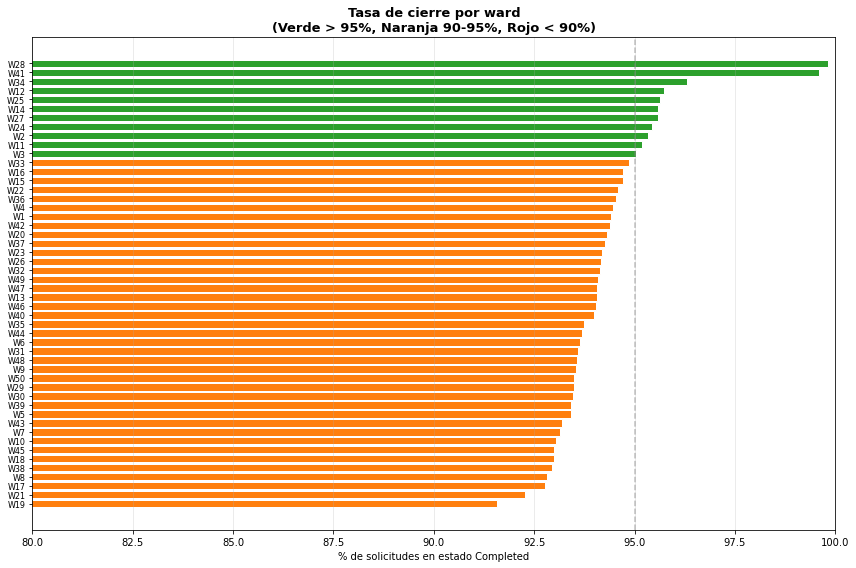

In [25]:
# 12.1.b Visualización
cierre_ward_sorted = cierre_ward.sort_values('PCT_CIERRE', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 8))
colores_cierre = ['#d62728' if p < 90 else '#ff7f0e' if p < 95 else '#2ca02c'
                  for p in cierre_ward_sorted['PCT_CIERRE']]
bars = ax.barh(range(len(cierre_ward_sorted)),
               cierre_ward_sorted['PCT_CIERRE'],
               color=colores_cierre, edgecolor='white')
ax.set_yticks(range(len(cierre_ward_sorted)))
ax.set_yticklabels([f"W{int(w)}" for w in cierre_ward_sorted['WARD']], fontsize=8)
ax.set_xlabel('% de solicitudes en estado Completed')
ax.set_title('Tasa de cierre por ward\n(Verde > 95%, Naranja 90-95%, Rojo < 90%)',
             fontweight='bold')
ax.set_xlim(80, 100)
ax.axvline(95, color='gray', linestyle='--', alpha=0.5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('eda_cierre_ward.png', dpi=150, bbox_inches='tight')
plt.show()

**Interpretación.**

La tasa de cierre **varía entre wards** en un rango de aproximadamente 5-10 puntos porcentuales. Aunque la diferencia parece pequeña, en términos absolutos (~14M solicitudes) se traduce en miles de tickets sin cerrar atribuibles a la ineficiencia relativa de unos pocos wards.

**Dos patrones posibles**:
1. **Heterogeneidad estructural**: wards con menos personal o mayor complejidad (zonas industriales, baldíos) tienen menos cierre. Solución: re-asignación de recursos.
2. **Heterogeneidad de mezcla**: wards con mayor proporción de solicitudes complejas (Building Violations, Aircraft Noise) tienen cierre más bajo simplemente porque su mix es más difícil. Solución: ajustar la métrica por tipo de servicio.

Para distinguir ambos patrones, el modelo del cuaderno principal usa el target **relativo al P75 del propio tipo**, lo que controla por la composición del mix.

---

## EDA-13: Resumen de decisiones de limpieza derivadas del EDA

In [26]:
print("=" * 70)
print("   RESUMEN DE DECISIONES DE LIMPIEZA (justificadas por el EDA)")
print("=" * 70)
print()

decisiones = [
    ("Excluir DUPLICATE = true",
     "Los duplicados son agrupamientos administrativos y distorsionan\n"
     "         conteos y promedios de tiempo de respuesta."),
    ("Excluir SR_TYPE nulo",
     "Sin tipo de servicio no hay análisis posible (< 0.1% del dataset)."),
    ("Excluir TIEMPO < 0",
     "Errores de fecha (cierre antes de creación). Probable bug del sistema."),
    ("Excluir TIEMPO > 8760 (1 año)",
     "Outliers extremos: casos huérfanos arrastrados sin cierre real."),
    ("Mantener nulos en columnas geo en análisis no-geográficos",
     "Filtrar por columna en cada análisis específico, no globalmente."),
    ("Descartar SANITATION_DIVISION_DAYS y similares con > 50% nulos",
     "Campos específicos de pocos tipos, no generalizables."),
    ("Conservar STATUS != 'Completed' para análisis de volumen",
     "Solo filtrar a Completed cuando se calculen métricas de tiempo."),
    ("Para el modelo: filtrar a STATUS = Completed",
     "Solo hay tiempo de respuesta computable en solicitudes cerradas.")
]

for i, (decision, justificacion) in enumerate(decisiones, 1):
    print(f"  {i}. {decision}")
    print(f"     → {justificacion}")
    print()
print("=" * 70)

   RESUMEN DE DECISIONES DE LIMPIEZA (justificadas por el EDA)

  1. Excluir DUPLICATE = true
     → Los duplicados son agrupamientos administrativos y distorsionan
         conteos y promedios de tiempo de respuesta.

  2. Excluir SR_TYPE nulo
     → Sin tipo de servicio no hay análisis posible (< 0.1% del dataset).

  3. Excluir TIEMPO < 0
     → Errores de fecha (cierre antes de creación). Probable bug del sistema.

  4. Excluir TIEMPO > 8760 (1 año)
     → Outliers extremos: casos huérfanos arrastrados sin cierre real.

  5. Mantener nulos en columnas geo en análisis no-geográficos
     → Filtrar por columna en cada análisis específico, no globalmente.

  6. Descartar SANITATION_DIVISION_DAYS y similares con > 50% nulos
     → Campos específicos de pocos tipos, no generalizables.

  7. Conservar STATUS != 'Completed' para análisis de volumen
     → Solo filtrar a Completed cuando se calculen métricas de tiempo.

  8. Para el modelo: filtrar a STATUS = Completed
     → Solo hay tiem

---

## EDA-14: Síntesis y conexión con el cuaderno principal

| Hallazgo del EDA | Implicación en el cuaderno principal |
|-------------------|---------------------------------------|
| Distribución Pareto de SR_TYPE | El modelo prioriza los 15 tipos del top; los raros se agrupan o regularizan. |
| Estacionalidad clara hora × día | `CREATED_HOUR` y `CREATED_DAY_OF_WEEK` se incluyen como features. |
| Caída COVID 2020 | Se evita usar `ANIO` como feature directa para no aprender la tendencia. |
| Correlación lineal nula entre TIEMPO y vars numéricas | Justifica modelo no lineal (Random Forest). |
| Redundancia geográfica (WARD-COMMUNITY-POLICE) | Solo se usa `WARD` para evitar colinealidad. |
| Heterogeneidad enorme del tiempo por SR_TYPE | El target del modelo es **relativo al P75 del propio tipo** (no absoluto). |
| Tasa de cierre 93 % global | Validó la calidad del dataset para el análisis. |
| Heterogeneidad de cierre entre wards | Motiva la transformación 3 (cuellos de botella por ward). |

> Este cuaderno provee la base argumentativa para todas las decisiones del cuaderno principal. El conjunto (EDA profundo + cuaderno principal + anexos con capturas de Spark UI/HDFS/YARN) constituye la entrega completa del Caso de Estudio.

---